# 04 Evaluation

Goal:
- Load saved metric table.
- Create report-ready comparison plots.
- Write interpretation notes for BAB IV.

In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
metrics = pd.read_csv("../reports/tables/model_metrics.csv")
metrics

,model,pr_auc,f1_suspicious,precision_suspicious,recall_suspicious,tp,fp,tn,fn,feature_set
0,random_forest,0.007962,0.000000,0.000000,0.000000,0,3,99848,149,raw
1,random_forest,0.007962,0.000000,0.000000,0.000000,0,3,99848,149,raw_plus_graph
2,xgboost,0.005373,0.006849,0.004598,0.013423,2,433,99418,147,raw
3,xgboost,0.005373,0.006849,0.004598,0.013423,2,433,99418,147,raw_plus_graph
4,lightgbm,0.003092,0.000000,0.000000,0.000000,0,184,99667,149,raw_plus_graph
5,lightgbm,0.003091,0.000000,0.000000,0.000000,0,184,99667,149,raw
6,logistic_regression,0.002806,0.003505,0.001761,0.355705,53,30042,69809,96,raw
7,logistic_regression,0.002806,0.003505,0.001761,0.355705,53,30042,69809,96,raw_plus_graph


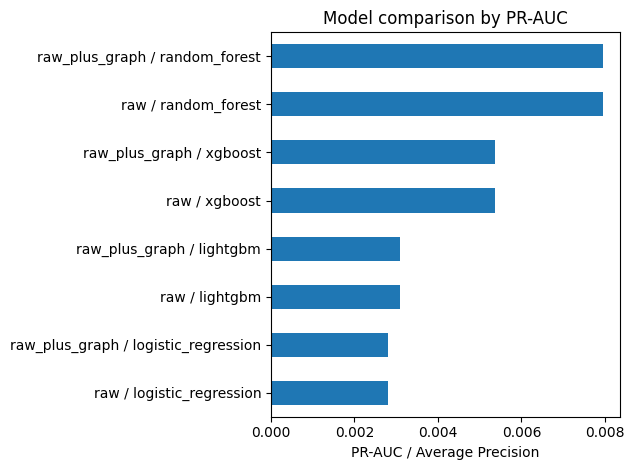

In [9]:
# PR-AUC comparison figure
plot_df = metrics.sort_values("pr_auc", ascending=True)
labels = plot_df["feature_set"] + " / " + plot_df["model"]

ax = plot_df.plot(kind="barh", x=None, y="pr_auc", legend=False)
ax.set_yticklabels(labels)
ax.set_title("Model comparison by PR-AUC")
ax.set_xlabel("PR-AUC / Average Precision")
plt.tight_layout()
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../reports/figures/model_pr_auc_comparison.png", dpi=150)
plt.show()

## BAB IV interpretation

Answer study questions:

- Which model has the highest PR-AUC?
- Did graph features improve PR-AUC or suspicious-class F1?
- Was recall improved at the cost of precision?
- Why is accuracy not emphasized?
- What graph features are likely useful?
- What are the false positive / false negative implications for AML analysts?